# Phase 5: Model Validation & Diagnostics

In [1]:
# Cell 1: Setup for Validation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
import joblib

# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# Load the trained model
rf_model = joblib.load('../src/random_forest_model.pkl')
print("Data and Model loaded for validation!")

Data and Model loaded for validation!


C:\Users\SHREYAS\AppData\Local\Temp\ipykernel_13160\1562135252.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


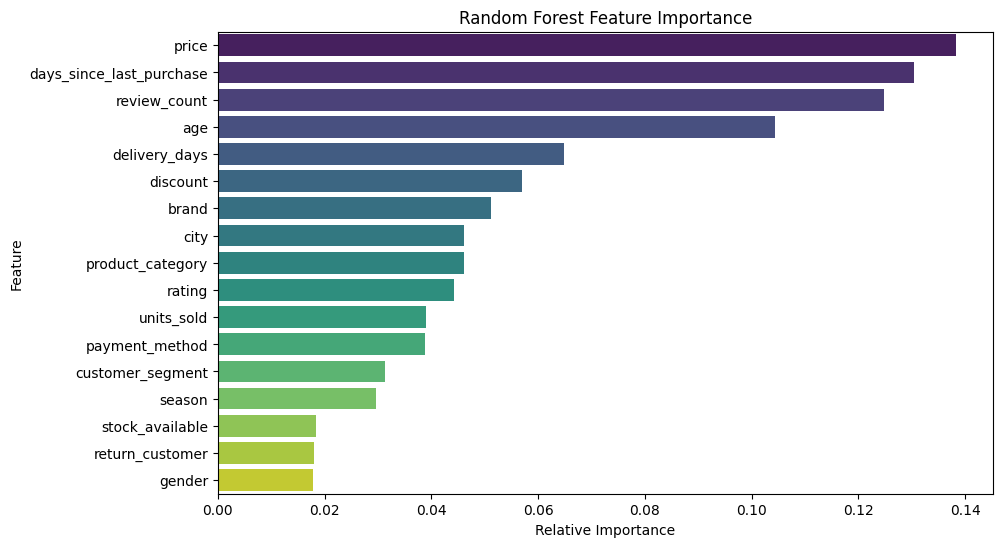

In [2]:
# Cell 2: Feature Importance Extraction
importances = rf_model.feature_importances_
features = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance')
plt.show()

In [3]:
# Cell 3: 5-Fold Cross Validation
print("Running 5-Fold Cross Validation... (This may take a minute)")

# Combine X and y back together just for the CV function
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

cv_scores = cross_val_score(rf_model, X_all, y_all, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Cross-Validation Accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")

Running 5-Fold Cross Validation... (This may take a minute)
Cross-Validation Accuracies: [0.5069551  0.50424494 0.5069924  0.51327937 0.50672013]
Mean CV Accuracy: 50.76%


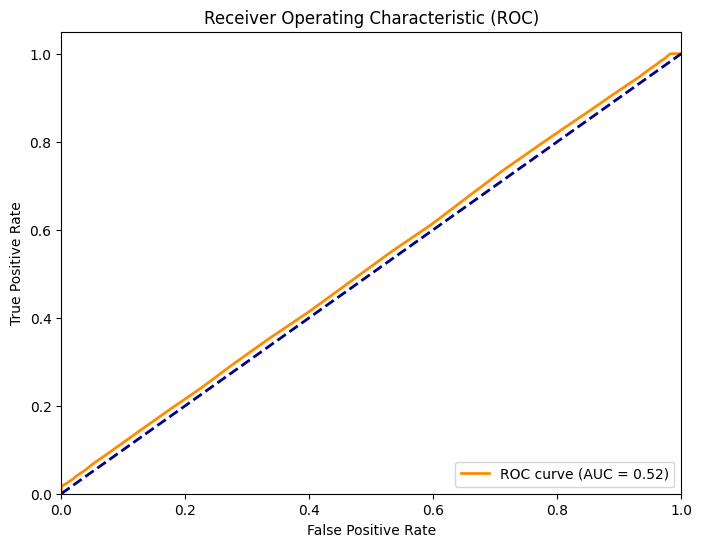

In [4]:
# Cell 4: ROC Curve
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()